<a href="https://colab.research.google.com/github/laurianedlz/Fundamentos-de-Optimizacion/blob/main/Practico_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejercicio computacional : GSS y grid search para comparar**
Sea la funcion $$f(x) = (x - 2)^2 + \sin(5x),$$

definida en el intervalo $x∈[0,4]$. El objectivo de este ejercicio es comparar las estrategias *Grid Search* y *Golden-Section Search*.


a) Graficar la funcion $f(x)$ en el intervalo $[0, 4]$. A partir de la grafica, identificar aproximadamente donde se encuentra el minimo.

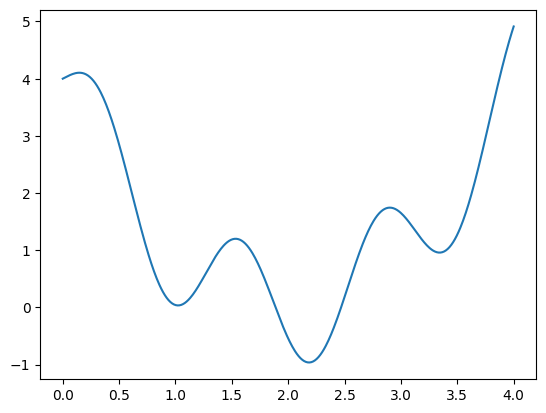

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return (x - 2)**2 + np.sin(5 * x)

x=np.linspace(0,4,500)
y=f(x)
plt.plot(x,y)

## El minimo se encontra aproximadamente en 2,2.

b) Implementar un método de Grid Search que evalue la funcion en $N$ puntos equiespaciados del
intervalo $[0, 4]$. Probar con distintos valores de $N$ (por ejemplo $N = 20, 50, 100, 500$).
Para cada
caso reportar:
* el valor estimado del minimo,
* la ubicacion del minimo,
* la cantidad de evaluaciones de la funcion.

In [33]:
def grid_search(f,a,b,N):
  x=np.linspace(a,b,N)
  y=f(x)
  minimo=np.min(y)
  ubicacion=x[np.argmin(y)]
  print("Para N = ",N,", la ubicacion del minimo es: ",ubicacion,"y el minimo vale",minimo)

grid_search(f,0,4,20)
grid_search(f,0,4,50)
grid_search(f,0,4,100)
grid_search(f,0,4,500)

Para N =  20 , la ubicacion del minimo es:  2.1052631578947367 y el minimo vale -0.8808235266966439
Para N =  50 , la ubicacion del minimo es:  2.204081632653061 y el minimo vale -0.9580423423698875
Para N =  100 , la ubicacion del minimo es:  2.181818181818182 y el minimo vale -0.9632047916801527
Para N =  500 , la ubicacion del minimo es:  2.1803607214428857 y el minimo vale -0.9630767604616721


In [34]:
phi=(np.sqrt(5)-1)/2
def golden_section_search(f,a,b,tol):
  x1=a+(b-a)*(1-phi)
  x2=a+(b-a)*phi
  f1=f(x1)
  f2=f(x2)
  n=1
  while np.abs(b-a)>tol:
      if f1<f2:
        b=x2
        x2=x1
        x1=a+(b-a)*(1-phi)
        f2=f1
        f1=f(x1)
      else:
        a=x1
        x1=x2
        x2=a+(b-a)*phi
        f1=f2
        f2=f(x2)
      n+=1
  ubicacion=(a+b)/2
  minimo=f(ubicacion)
  print ("Para tolerencia =",tol," el algoritmo convergio en ",n,"iteraciones, la ubicacion del minimo es:",ubicacion,"y el minimo vale",minimo)

golden_section_search(f,0,4,1e-6)
golden_section_search(f,0,4,1e-8)
golden_section_search(f,0,4,1e-10)

Para tolerencia = 1e-06  el algoritmo convergio en  33 iteraciones, la ubicacion del minimo es: 2.184353424624136 y el minimo vale -0.963291302311137
Para tolerencia = 1e-08  el algoritmo convergio en  43 iteraciones, la ubicacion del minimo es: 2.1843532045414014 y el minimo vale -0.963291302311803
Para tolerencia = 1e-10  el algoritmo convergio en  52 iteraciones, la ubicacion del minimo es: 2.184353203993628 y el minimo vale -0.9632913023118029


c) Comparar los resultados obtenidos con ambos métodos. Discutir:
* precision de la solucion obtenida,
* cantidad de evaluaciones de la funcion,
* ventajas y desventajas de cada método.

¿Cuando podria ser preferible utilizar Grid Search en lugar de Golden Section Search?

Podemos ver que el *Golden Section Search* necesita menos evaluaciones de la function que el *Grid Search* para encontrar una solucion mas precisa. Ademas, si queremos buscar un minimo en un intervalo mas grande, tendremos que evaluar muchos mas puntos en el *Grid Search* si queremos la misma precision mientras que el *Golden Section Search* no tendremos tantas evaluaciones mas.

Sin embargo el *Golden Section Search* no siempre puede encontrar el minimo global porque si la function sobre cual trabajamos tiene oscilaciones, se puede que el algoritmo no vea el minimo real pero solo un minimo local, en este caso es preferible utilizar *Grid Search*.
Sino, para estar seguro de que el algoritmo va a encontrar el minimo global, tenemos que tener un unico minimo en nuestra funcion(minimo unimodal).

d) Consideremos ahora la funcion
$$g(x) = sin(6x) + 0,2x,$$

definida en el intervalo $x ∈ [0, 4]$. Comparar los resultados obtenidos con *Grid Search* y *Golden
Section Search* para $g$.

¿Ambos métodos encuentran el mismo minimo? ¿Por qué?


Para N =  100 , la ubicacion del minimo es:  0.7676767676767677 y el minimo vale -0.8408171086721457
Para tolerencia = 1e-06  el algoritmo convergio en  33 iteraciones, la ubicacion del minimo es: 0.779841393863787 y el minimo vale -0.843475974332937


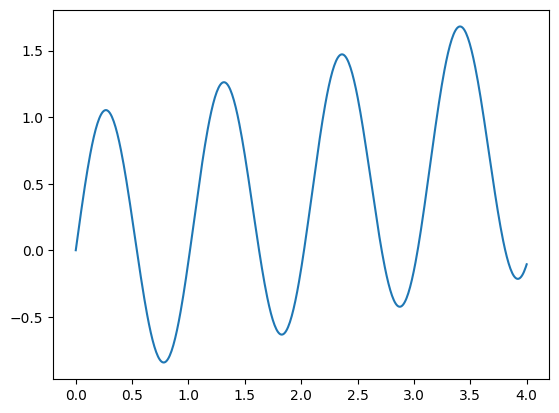

In [35]:
def g(x):
  return np.sin(6*x)+0.2*x

grid_search(g,0,4,100)
golden_section_search(g,0,4,1e-6)

x=np.linspace(0,4,500)
y=g(x)
plt.plot(x,y)

Ambos metodos encuentran el mismo minimo. Pero tenemos mucha suerte para el *Golden Section Search* porque hay 4 minimos locales. Por ejemplo, cuando buscamos el minimo en el intervalo $[0,10]$, no encontramos el minimo global, solo un minimo local.

Para N =  100 , la ubicacion del minimo es:  0.8080808080808081 y el minimo vale -0.8291370813895155
Para tolerencia = 1e-06  el algoritmo convergio en  35 iteraciones, la ubicacion del minimo es: 3.9214342444899675 y el minimo vale -0.21515744361558897


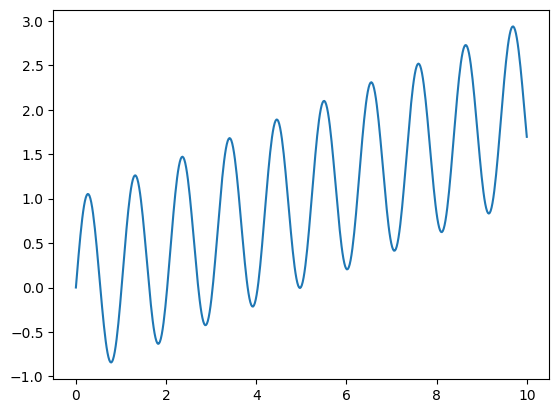

In [36]:
grid_search(g,0,10,100)
golden_section_search(g,0,10,1e-6)

x=np.linspace(0,10,500)
y=g(x)
plt.plot(x,y)